Plotting the rayleigh and polar plot for some hdir cells

In [1]:
from behave_analysis.database.Experiments.JAL004_ex import JAL4_3rdSept, JAL4_19thSept, JAL4_11thSept, JAL4_28aug

from behave_analysis.database.Experiments.JAL005_ex import JAL005_8thSept, JAL005_21stSept, JAL005_5thSept

from behave_analysis.database.Experiments.JAL006_ex import JAL6_flip3_18mar, JAL6_flip7_1apr, JAL6_28mar, JAL6_flip4_21mar, JAL6_flip5_25mar

from behave_analysis.database.Experiments.JAL007_ex import JAL7_sesh8_9apr, JAL7_sesh9_16apr, JAL7_flip5_22mar, JAL7_flip2_12mar, JAL7_23apr

from behave_analysis.database.Experiments.JAL008_ex import JAL8_flip3_7may, JAL8_flip1_25apr, JAL8_flip2_29apr, JAL8_flip4_10may, JAL8_14may

experiments_objects = [JAL4_3rdSept, JAL4_19thSept, JAL4_28aug, JAL4_11thSept,
JAL005_8thSept, JAL005_21stSept, # JAL005_5thSept this one doesn't flip, but can be used as first barrier appearance
JAL6_28mar, JAL6_flip4_21mar, JAL6_flip3_18mar, JAL6_flip5_25mar, # (unmatched number of neurons and cluster ids) # JAL6_flip7_1apr, # this session is sus
JAL7_sesh8_9apr, JAL7_flip5_22mar, JAL7_flip2_12mar, JAL7_sesh9_16apr, JAL7_23apr,
JAL8_flip1_25apr,JAL8_flip2_29apr, JAL8_flip3_7may, JAL8_14may, JAL8_flip4_10may]

session_names = ["JAL4_3rdSept","JAL4_19thSept","JAL4_28aug","JAL4_11thSept",
    "JAL5_8thSept","JAL5_21stSept",
    "JAL6_28mar", "JAL6_flip4_21mar", "JAL6_flip3_18mar", "JAL6_flip5_25mar", 
    "JAL7_sesh8_9apr", "JAL7_flip5_22mar", "JAL7_flip2_12mar", "JAL7_sesh9_16apr", "JAL7_23apr",
    "JAL8_flip1_25apr", "JAL8_flip2_29apr", "JAL8_flip3_7may",  "JAL8_14may", "JAL8_flip4_10may"] 

In [22]:
%load_ext autoreload
%autoreload 2
from behave_analysis.utils.rayleigh.load_rayleigh import extract_rayleigh_path, load_rayleigh_data
from behave_analysis.process.process import Process
from behave_analysis.analyze.Rayleigh.computeRayleigh import polar_plot
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
import dill as pickle
from pathlib import Path
import os

import matplotlib
matplotlib.rcParams['font.family'] = 'Arial'
matplotlib.rcParams['font.size'] = 15
matplotlib.rcParams['pdf.fonttype'] = 42  # Ensure fonts are embedded in PDF

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
dir = Path("Z:\Jasmine_Laurence\single_trial_overview\decoding_spatial_efficiency\head_direction_cells.pkl")
with open(dir, "rb") as dill_file:
    hdir = pickle.load(dill_file)

2026-03-12 20:17:26.117 | INFO     | behave_analysis.process.process:load_session:117 - All data has been moved from winstor to ceph so we always load ceph data now


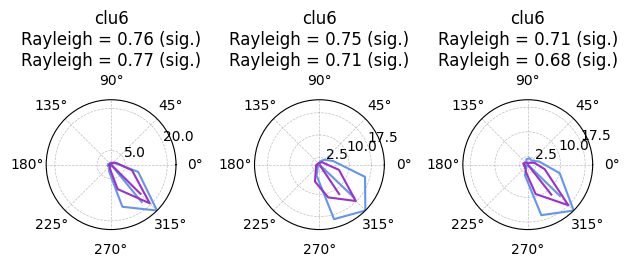

In [5]:
"""Make a plot of the Rayleigh results for a head direction cell across the three conditions"""
condition = ['shelter_only', 'barrier_pre_flip', 'barrier_post_flip']
n = 0 # neuron
e = 0 # session
session = Process(experiments_objects[e]).load_session()
hdir_n = hdir[session_names[e]]
fig, ax = plt.subplots(1,len(condition), subplot_kw={'projection': 'polar'})
rayleighs = np.array([])
r_theta = np.array([])
angles = np.array([])
for i, c in enumerate(condition):
    path = extract_rayleigh_path(session, 'good', condition=c, file_name="hdir_Rayleigh.arrow")
    data = load_rayleigh_data(path)
    rayleighs = np.append(rayleighs, data.filter(data['clusterID']==hdir_n[n])['Rayleigh'].to_numpy())
    r_theta = np.append(r_theta, data.filter(data['clusterID']==hdir_n[n])['Rayleigh_theta'].to_numpy())
    angles = np.append(angles, data.filter(data['clusterID']==hdir_n[n])['angles'].to_numpy().T)
    fr = data.filter(data['clusterID']==hdir_n[n])['angle_firing_hist'].to_numpy()
    fr = np.reshape(
    fr, [int(np.shape(data.filter(data['clusterID']==hdir_n[n])["angles"].to_list())[1]), int(np.shape(fr)[1] / np.shape(data.filter(data['clusterID']==hdir_n[n])["angles"].to_list())[1])]
        )
    if i == 0:
        angle_firing = fr.T
    else:
        angle_firing = np.append(angle_firing, fr.T, axis=0)
    polar_plot(data.filter(data['clusterID']==hdir_n[n]), ax[i], fig, plot_type="line")
plt.tight_layout()

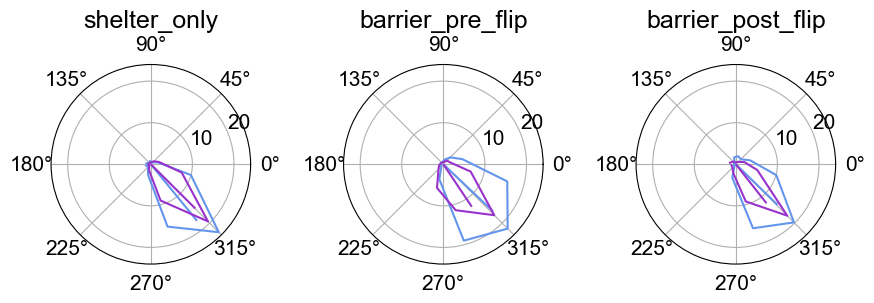

In [25]:
fig, ax = plt.subplots(1,len(condition), figsize=(9, 4), subplot_kw={'projection': 'polar'})
idx = [0,2,4]
col = ["cornflowerblue", "darkorchid"]
for i, c in enumerate(condition):
    for j in range(2):
        ax[i].plot(angles[:angle_firing.shape[1]], angle_firing[idx[i]+j,:], color=col[j], linewidth=1.5)
        ax[i].vlines(r_theta[idx[i]+j], 0, rayleighs[idx[i]+j]*np.max(angle_firing[idx[i]+j,:]), color=col[j], linewidth=1.5)
    ax[i].set_title(c)
    ax[i].set_ylim(bottom=0, top=np.ceil(np.amax(angle_firing)))  # set the y-axis limits to the max firing rate to make the plot more readable
plt.tight_layout()

In [17]:
hdir_sesh = []
for idx, exp in enumerate(experiments_objects):
    session = Process(exp).load_session()
    clu_Ids = np.load(os.path.join(session.base_path, session.processed_path)
        + "\\"
        + "good_cluster_Ids.npy"
    )

    hdir_n = hdir[session_names[idx]]
    hdir_sesh.append(len(hdir_n)/len(clu_Ids))

2026-03-12 20:24:51.757 | INFO     | behave_analysis.process.process:load_session:117 - All data has been moved from winstor to ceph so we always load ceph data now
2026-03-12 20:24:51.862 | INFO     | behave_analysis.process.process:load_session:117 - All data has been moved from winstor to ceph so we always load ceph data now
2026-03-12 20:24:51.926 | INFO     | behave_analysis.process.process:load_session:117 - All data has been moved from winstor to ceph so we always load ceph data now
2026-03-12 20:24:52.015 | INFO     | behave_analysis.process.process:load_session:117 - All data has been moved from winstor to ceph so we always load ceph data now
2026-03-12 20:24:52.093 | INFO     | behave_analysis.process.process:load_session:117 - All data has been moved from winstor to ceph so we always load ceph data now
2026-03-12 20:24:52.184 | INFO     | behave_analysis.process.process:load_session:117 - All data has been moved from winstor to ceph so we always load ceph data now
2026-03-12

(0.0, 1.0)

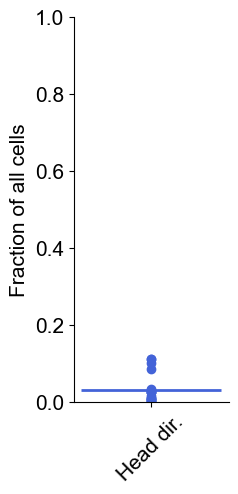

In [26]:
"""Overview plot across sessions as a scatter plot"""
fig, ax = plt.subplots(1, 1, figsize=(2, 5))
ax.scatter(np.zeros_like(hdir_sesh), hdir_sesh, color = "#4363d8")
ax.hlines(np.mean(hdir_sesh), 0 - 0.2, 0 + 0.2, color="#4363d8", linewidth=2)
ax.set_xticks([0])
ax.set_xticklabels(["Head dir."], rotation=45)
ax.set_ylabel('Fraction of all cells')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylim(0, 1)